### load package


In [52]:
# Load packages
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import os
import cmaps
from matplotlib.colors import LinearSegmentedColormap
from metpy.calc import relative_humidity_from_specific_humidity
from metpy.units import units
print("="*70)
print("✅ Packages loaded successfully")
print("="*70)

# Set up directories
DATA_DIR = "./processed_data"
fig_save_dir = "./figures/Cal_rh_tas/"
os.makedirs(fig_save_dir, exist_ok=True)

print(f"📁 Data directory: {DATA_DIR}")
print(f"📁 Figure save directory: {fig_save_dir}")
print("="*70)

# Create custom colormap
def create_improved_colormap():
    """Create improved red-white-blue colormap"""
    colors = ['#00008B', '#0000FF', '#4169E1', '#87CEEB', '#E0F6FF',
              '#FFFFFF', 
              '#FFE0E0', '#FFB6C1', '#FF6B6B', '#FF0000', '#8B0000']
    return LinearSegmentedColormap.from_list('improved_bwr', colors, N=256)

mycmap = create_improved_colormap()

✅ Packages loaded successfully
📁 Data directory: ./processed_data
📁 Figure save directory: ./figures/Cal_rh_tas/


In [53]:
# Load ocean mask
print("="*70)
print("🌊 Loading ocean mask")
print("="*70)

ocean_mask_path = os.path.join(DATA_DIR, "ocean_mask_2deg.nc")
if os.path.exists(ocean_mask_path):
    ocean_mask_2deg_binary = xr.open_dataarray(ocean_mask_path)
    print(f"✅ Ocean mask loaded! Shape: {ocean_mask_2deg_binary.shape}")
else:
    print("⚠️  Ocean mask not found, will process all data without masking")
    ocean_mask_2deg_binary = None

print("="*70)

🌊 Loading ocean mask
✅ Ocean mask loaded! Shape: (15, 180)


In [54]:
# Define experiments
experiments = ['cntl', 'p4k', '4co2']
exp_names = {
    'cntl': 'Control',
    'p4k': '+4K',
    '4co2': '4×CO₂'
}

# Define data paths
data_2d_dir = os.path.join(DATA_DIR, "2d_layers")

# Load data for all experiments
print("="*70)
print("📊 Loading 2D data (tas, hus2m, ps) for all experiments")
print("="*70)

tas_data = {}
hus2m_data = {}
ps_data = {}

for exp in experiments:
    print(f"\n🔄 Loading {exp_names[exp]} experiment...")
    
    # Load tas (2m temperature)
    tas_path = os.path.join(data_2d_dir, f"tas_{exp}", "tas_2deg_interp.nc")
    tas_data[exp] = xr.open_dataset(tas_path)['tas']
    print(f"  ✅ tas: {tas_data[exp].shape}")
    
    # Load hus2m (2m specific humidity)
    hus2m_path = os.path.join(data_2d_dir, f"hus2m_{exp}", "hus2m_2deg_interp.nc")
    hus2m_data[exp] = xr.open_dataset(hus2m_path)['hus2m']
    print(f"  ✅ hus2m: {hus2m_data[exp].shape}")
    
    # Load ps (surface pressure)
    ps_path = os.path.join(data_2d_dir, f"ps_{exp}", "ps_2deg_interp.nc")
    ps_data[exp] = xr.open_dataset(ps_path)['ps']
    print(f"  ✅ ps: {ps_data[exp].shape}")

print("\n" + "="*70)
print("✅ All data loaded successfully!")
print("="*70)

📊 Loading 2D data (tas, hus2m, ps) for all experiments

🔄 Loading Control experiment...
  ✅ tas: (5114, 15, 180)
  ✅ hus2m: (5114, 15, 180)
  ✅ ps: (5114, 15, 180)

🔄 Loading +4K experiment...
  ✅ tas: (5114, 15, 180)
  ✅ hus2m: (5114, 15, 180)
  ✅ ps: (5114, 15, 180)

🔄 Loading 4×CO₂ experiment...
  ✅ tas: (5114, 15, 180)
  ✅ hus2m: (5114, 15, 180)
  ✅ ps: (5114, 15, 180)

✅ All data loaded successfully!


In [55]:
# Calculate climatology (time mean)
print("="*70)
print("📈 Calculating climatology (time mean)")
print("="*70)

tas_clim = {}
hus2m_clim = {}
ps_clim = {}

for exp in experiments:
    print(f"  🔄 {exp_names[exp]}...")
    tas_clim[exp] = tas_data[exp].mean(dim='time')
    hus2m_clim[exp] = hus2m_data[exp].mean(dim='time')
    ps_clim[exp] = ps_data[exp].mean(dim='time')

print("✅ Climatology calculated!")
print("="*70)

📈 Calculating climatology (time mean)
  🔄 Control...


  🔄 +4K...
  🔄 4×CO₂...
✅ Climatology calculated!


In [56]:
def calculate_relative_humidity_metpy(hus, ps, tas):
    """
    Calculate relative humidity using MetPy
    
    Parameters:
    -----------
    hus : xarray.DataArray
        Specific humidity at 2m (kg/kg)
    ps : xarray.DataArray
        Surface pressure (Pa)
    tas : xarray.DataArray
        Temperature at 2m (K)
    
    Returns:
    --------
    rh : xarray.DataArray
        Relative humidity (%)
    """
    # Convert xarray DataArrays to numpy arrays and add units
    pressure = ps.values / 100.0 * units.hPa  # Pa → hPa
    temperature = (tas.values - 273.15) * units.degC  # K → °C
    specific_humidity = hus.values * units('dimensionless')
    
    # Calculate relative humidity using MetPy
    rh = relative_humidity_from_specific_humidity(pressure, temperature, specific_humidity)
    rh_percent = rh.to('percent').magnitude
    
    # Create xarray DataArray with same coordinates
    rh_da = xr.DataArray(
        rh_percent,
        coords=hus.coords,
        dims=hus.dims,
        attrs={'units': '%', 'long_name': 'Relative Humidity'}
    )
    
    return rh_da.clip(0, 100)





def plot_spatial_maps(data_dict, exp_names, title, cbar_label, 
                      levels, cmap, fig_name, fig_save_dir, 
                      ocean_mask=None, show_land=False, ocean_only=False):
    """
    Efficient function to plot spatial maps for multiple experiments
    
    Parameters:
    -----------
    data_dict : dict
        Dictionary with experiment names as keys and xarray DataArrays as values
    exp_names : dict
        Dictionary mapping experiment codes to display names
    title : str
        Main title for the figure
    cbar_label : str
        Label for colorbar
    levels : array-like
        Contour levels
    cmap : str or colormap
        Colormap to use
    fig_name : str
        Filename to save the figure
    fig_save_dir : str
        Directory to save the figure
    ocean_mask : xarray.DataArray, optional
        Ocean mask (1 for ocean, NaN for land)
    show_land : bool, optional
        Whether to show land in gray (default: False)
    ocean_only : bool, optional
        If True, only plot ocean regions (default: False)
    
    Returns:
    --------
    fig, axes : matplotlib figure and axes objects
    """
    n_exp = len(data_dict)
    fig, axes = plt.subplots(n_exp, 1, figsize=(12, 3*n_exp), 
                             subplot_kw={'projection': ccrs.PlateCarree(180)})
    
    if n_exp == 1:
        axes = [axes]
    title_label = ['(a)', '(b)', '(c)']  # Extend as needed
    for idx, (exp_code, exp_name) in enumerate(exp_names.items()):
        ax = axes[idx]
        
        # Apply ocean mask if ocean_only is True
        if ocean_only and ocean_mask is not None:
            plot_data = data_dict[exp_code].where(ocean_mask == 1)
        else:
            plot_data = data_dict[exp_code]
        
        # Plot data
        im = ax.contourf(plot_data.lon, plot_data.lat, plot_data,
                        levels=levels, cmap=cmap,
                        extend='both', transform=ccrs.PlateCarree())
        
        # Add features
        ax.coastlines(linewidth=0.5)
        
        ax.set_extent([-180, 180, -20, 20], crs=ccrs.PlateCarree())
        
        # Set title
        ax.set_title(f"{title_label[idx]} {exp_name}", fontsize=14, loc='left')
        
        # Add gridlines
        gl = ax.gridlines(draw_labels=True, linewidth=0., alpha=0.5, linestyle='--')
        gl.top_labels = False
        gl.right_labels = False
    
    # Add colorbar
    cbar = plt.colorbar(im, ax=axes, orientation='horizontal', 
                       pad=0.05, shrink=0.8, aspect=35)
    cbar.set_label(cbar_label, fontsize=12)
    
    plt.suptitle(title, fontsize=16, y=1.02)
    
    # Save figure
    save_path = os.path.join(fig_save_dir, fig_name)
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"✅ Figure saved: {save_path}")
    
    return fig, axes


def plot_difference_maps(diff_dict, exp_names, title, cbar_label,
                        levels, cmap, fig_name, fig_save_dir,
                        ocean_mask=None, show_land=True, ocean_only=False,
                        add_zonal_mean=True):
    """
    Plot spatial difference maps with optional zonal mean
    
    Parameters:
    -----------
    diff_dict : dict
        Dictionary with experiment names as keys and difference DataArrays as values
    exp_names : dict
        Dictionary mapping experiment codes to display names
    title : str
        Main title for the figure
    cbar_label : str
        Label for colorbar
    levels : array-like
        Contour levels
    cmap : str or colormap
        Colormap to use
    fig_name : str
        Filename to save the figure
    fig_save_dir : str
        Directory to save the figure
    ocean_mask : xarray.DataArray, optional
        Ocean mask (1 for ocean, NaN for land)
    show_land : bool, optional
        Whether to show land in gray (default: True)
    ocean_only : bool, optional
        If True, only calculate/plot ocean regions (default: False)
    add_zonal_mean : bool, optional
        If True, add zonal mean panel on the right (default: True)
    
    Returns:
    --------
    fig, axes : matplotlib figure and axes objects
    """
    n_exp = len(diff_dict)
    
    if add_zonal_mean:
        fig = plt.figure(figsize=(16, 4*n_exp))
        gs = fig.add_gridspec(n_exp, 2, width_ratios=[4, 1], wspace=0.3, hspace=0.3)
    else:
        fig, axes = plt.subplots(n_exp, 1, figsize=(12, 4*n_exp),
                                subplot_kw={'projection': ccrs.PlateCarree(180)})
        if n_exp == 1:
            axes = [axes]
    
    for idx, (exp_code, exp_name) in enumerate(exp_names.items()):
        # Create map subplot
        if add_zonal_mean:
            ax_map = fig.add_subplot(gs[idx, 0], projection=ccrs.PlateCarree(180))
            ax_zonal = fig.add_subplot(gs[idx, 1])
        else:
            ax_map = axes[idx]
        
        # Apply ocean mask if ocean_only is True
        if ocean_only and ocean_mask is not None:
            plot_data = diff_dict[exp_code].where(ocean_mask == 1)
        else:
            plot_data = diff_dict[exp_code]
        
        # Plot spatial map
        im = ax_map.contourf(plot_data.lon, plot_data.lat, plot_data,
                            levels=levels, cmap=cmap,
                            extend='both', transform=ccrs.PlateCarree())
        
        # Add features
        ax_map.coastlines(linewidth=0.5)
        
        ax_map.set_extent([-180, 180, -20, 20], crs=ccrs.PlateCarree())
        
        # Set title
        ax_map.set_title(exp_name, fontsize=14, loc='left')
        
        # Add gridlines
        gl = ax_map.gridlines(draw_labels=True, linewidth=0., alpha=0.5, linestyle='--')
        gl.top_labels = False
        gl.right_labels = False
        
        # Plot zonal mean if requested
        if add_zonal_mean:
            zonal_mean = plot_data.mean(dim='lon', skipna=True)
            ax_zonal.plot(zonal_mean, zonal_mean.lat, 'k-', linewidth=2)
            ax_zonal.axvline(0, color='gray', linestyle='--', linewidth=0.8)
            ax_zonal.set_ylim(-20, 20)
            ax_zonal.set_xlabel('Zonal Mean', fontsize=11)
            ax_zonal.set_ylabel('Latitude', fontsize=11)
            ax_zonal.grid(True, alpha=0.3)
            ax_zonal.set_title('Zonal Mean', fontsize=12)
    
    # Add colorbar
    if add_zonal_mean:
        cbar_ax = fig.add_axes([0.15, 0.02, 0.5, 0.015])
        cbar = plt.colorbar(im, cax=cbar_ax, orientation='horizontal')
    else:
        cbar = plt.colorbar(im, ax=axes, orientation='horizontal',
                          pad=0.05, shrink=0.8, aspect=35)
    cbar.set_label(cbar_label, fontsize=12)
    
    plt.suptitle(title, fontsize=16, y=0.98)
    
    # Save figure
    save_path = os.path.join(fig_save_dir, fig_name)
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"✅ Figure saved: {save_path}")
    
    return fig





🎨 Plotting tas climatology spatial distribution
✅ Figure saved: ./figures/Cal_rh_tas/tas_climatology_3experiments_ocean.png


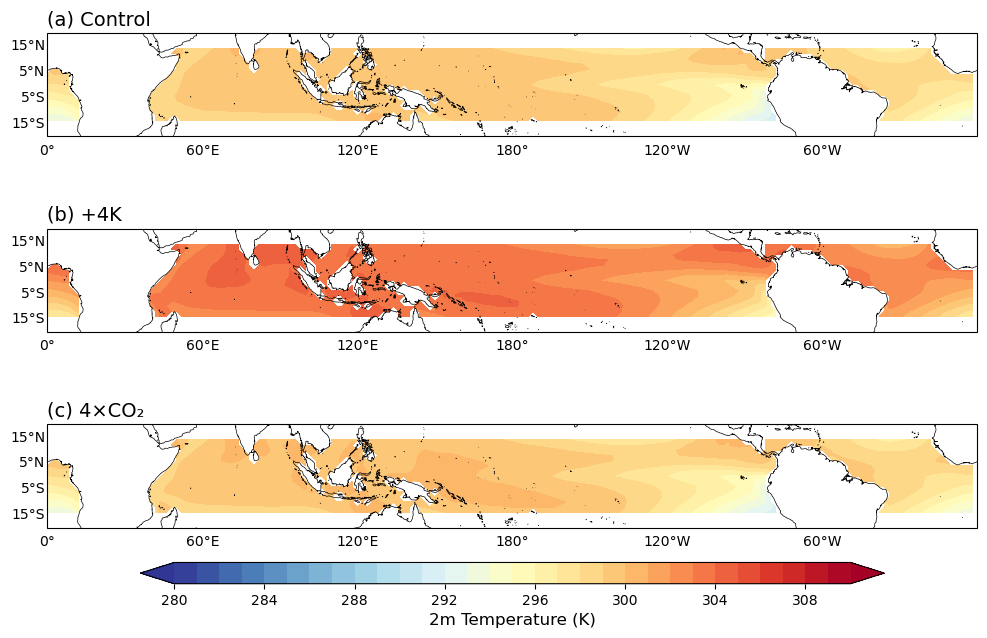

In [57]:
# Plot tas climatology - Ocean only option
print("="*70)
print("🎨 Plotting tas climatology spatial distribution")
print("="*70)

# You can control ocean_only parameter here
OCEAN_ONLY = True  # Set to True to show only ocean, False to show all regions

fig, axes = plot_spatial_maps(
    data_dict=tas_clim,
    exp_names=exp_names,
    title='' ,
    cbar_label='2m Temperature (K)',
    levels=np.linspace(280, 310, 31),
    cmap='RdYlBu_r',
    fig_name=f'tas_climatology_3experiments{"_ocean" if OCEAN_ONLY else ""}.png',
    fig_save_dir=fig_save_dir,
    ocean_mask=ocean_mask_2deg_binary,
    show_land=True,
    ocean_only=OCEAN_ONLY
)

plt.show()
print("="*70)

In [58]:
# Calculate relative humidity for all experiments
print("="*70)
print("🌡️  Calculating relative humidity climatology (using MetPy)")
print("="*70)

rh_clim = {}

for exp in experiments:
    print(f"  🔄 {exp_names[exp]}...")
    rh_clim[exp] = calculate_relative_humidity_metpy(hus2m_clim[exp], ps_clim[exp], tas_clim[exp])
    
    # Print statistics
    rh_mean = float(rh_clim[exp].mean())
    rh_min = float(rh_clim[exp].min())
    rh_max = float(rh_clim[exp].max())
    print(f"     Mean: {rh_mean:.2f}%, Min: {rh_min:.2f}%, Max: {rh_max:.2f}%")

print("\n✅ Relative humidity calculated!")
print("="*70)



🌡️  Calculating relative humidity climatology (using MetPy)
  🔄 Control...
     Mean: 73.46%, Min: 24.66%, Max: 92.64%
  🔄 +4K...
     Mean: 74.02%, Min: 23.45%, Max: 92.54%
  🔄 4×CO₂...
     Mean: 74.22%, Min: 29.57%, Max: 93.21%

✅ Relative humidity calculated!


🎨 Plotting relative humidity spatial distribution
✅ Figure saved: ./figures/Cal_rh_tas/rh_2m_climatology_ocean_3experiments.png


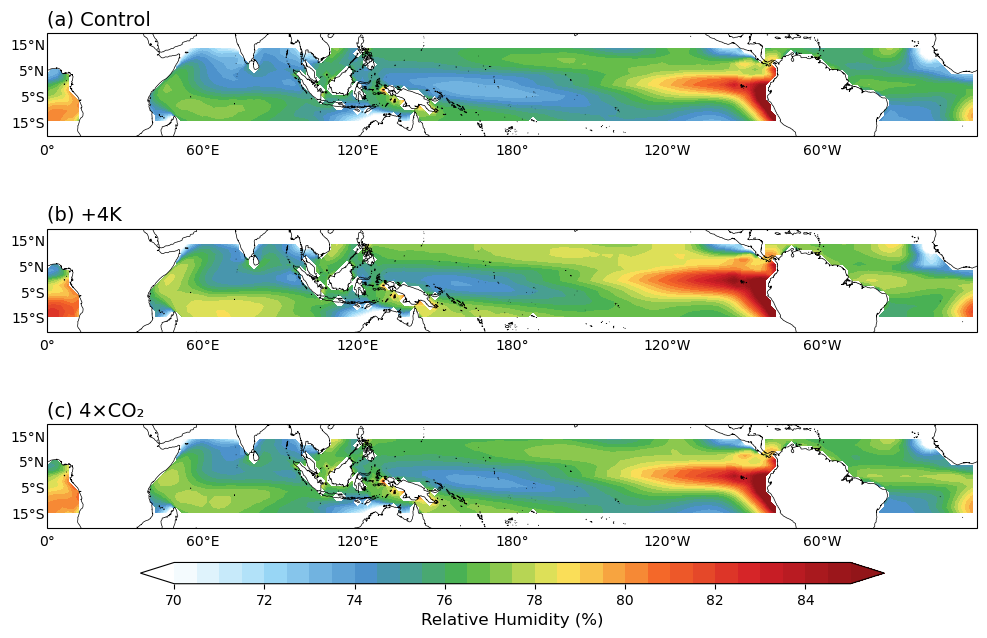


📊 Statistics:
  Control: Ocean mean RH = 75.69%
  +4K: Ocean mean RH = 76.90%
  4×CO₂: Ocean mean RH = 76.39%


In [72]:
# Plot relative humidity - Ocean only option
print("="*70)
print("🎨 Plotting relative humidity spatial distribution")
print("="*70)

# Control parameter for ocean-only display
OCEAN_ONLY = True  # Set to True to show only ocean, False to show all regions
  # Custom colormap for RH
fig, axes = plot_spatial_maps(
    data_dict=rh_clim,
    exp_names=exp_names,
    title='',
    cbar_label='Relative Humidity (%)',
    levels=np.linspace(70, 85, 31),
    cmap=cmaps.WhiteBlueGreenYellowRed,
    fig_name=f'rh_2m_climatology{"_ocean" if OCEAN_ONLY else ""}_3experiments.png',
    fig_save_dir=fig_save_dir,
    ocean_mask=ocean_mask_2deg_binary,
    show_land=True,
    ocean_only=OCEAN_ONLY
)

plt.show()

# Print statistics
print("\n📊 Statistics:")
for exp in experiments:
    if OCEAN_ONLY:
        rh_ocean_data = rh_clim[exp].where(ocean_mask_2deg_binary == 1)
        ocean_mean = float(rh_ocean_data.mean(skipna=True))
        print(f"  {exp_names[exp]}: Ocean mean RH = {ocean_mean:.2f}%")
    else:
        global_mean = float(rh_clim[exp].mean(skipna=True))
        print(f"  {exp_names[exp]}: Global mean RH = {global_mean:.2f}%")

print("="*70)

### Calculate differences: p4k - cntl and 4co2 - cntl

In [69]:
# Calculate differences for all variables
print("="*70)
print("📊 Calculating differences: p4k - cntl and 4co2 - cntl")
print("="*70)

# Temperature differences
tas_diff = {
    'p4k': tas_clim['p4k'] - tas_clim['cntl'],
    '4co2': tas_clim['4co2'] - tas_clim['cntl']
}

# Relative humidity differences
rh_diff = {
    'p4k': rh_clim['p4k'] - rh_clim['cntl'],
    '4co2': rh_clim['4co2'] - rh_clim['cntl']
}

# Specific humidity differences
hus2m_diff = {
    'p4k': hus2m_clim['p4k'] - hus2m_clim['cntl'],
    '4co2': hus2m_clim['4co2'] - hus2m_clim['cntl']
}

# Define experiment names for difference plots
diff_exp_names = {
    'p4k': '+4K - Control',
    '4co2': '4×CO₂ - Control'
}

print("✅ Differences calculated!")
print("\n📈 Summary statistics for differences:")


📊 Calculating differences: p4k - cntl and 4co2 - cntl
✅ Differences calculated!

📈 Summary statistics for differences:


### Plot spatial difference maps with zonal means

🎨 Plotting relative humidity difference spatial maps with zonal means
✅ Figure saved: ./figures/Cal_rh_tas/rh_difference_ocean_with_zonal.png


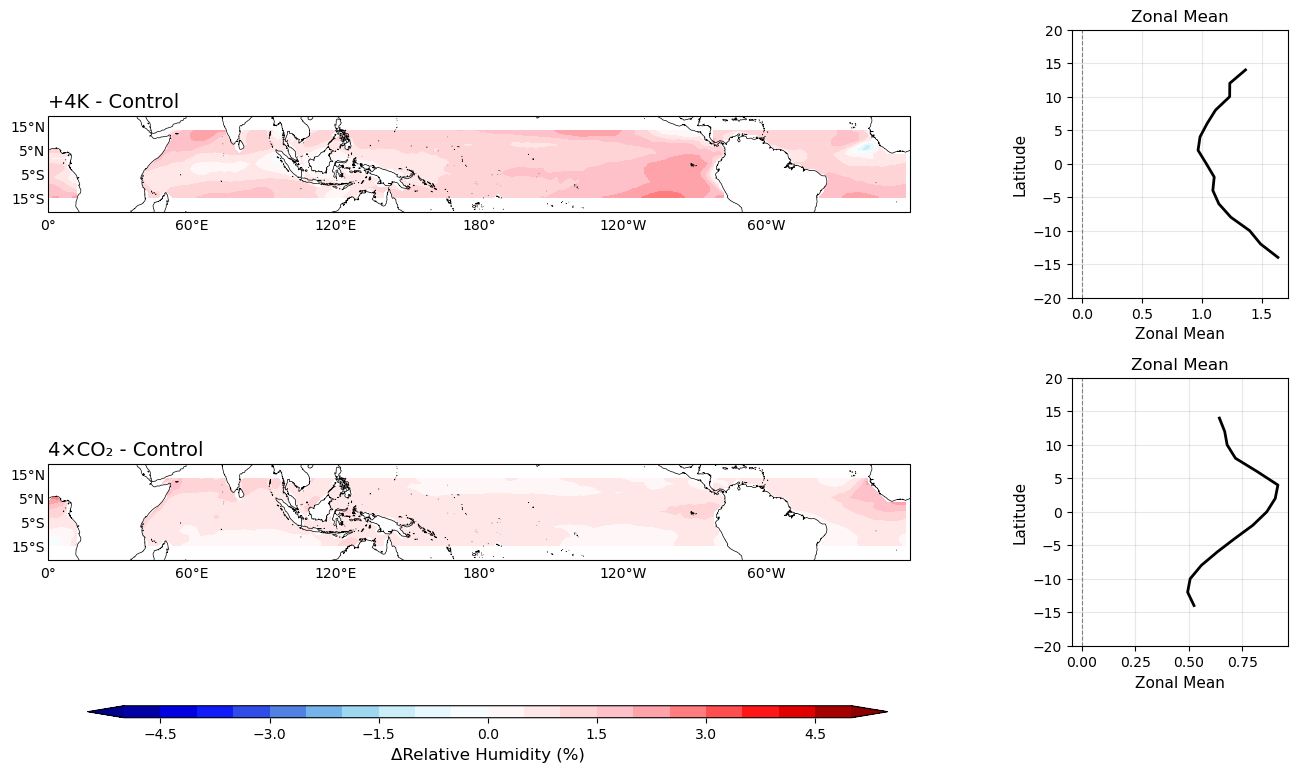

In [70]:
# Plot relative humidity difference maps
print("="*70)
print("🎨 Plotting relative humidity difference spatial maps with zonal means")
print("="*70)

OCEAN_ONLY = True  # Control ocean-only display

fig = plot_difference_maps(
    diff_dict=rh_diff,
    exp_names=diff_exp_names,
    title='',
    cbar_label='ΔRelative Humidity (%)',
    levels=np.linspace(-5, 5, 21),
    cmap=mycmap,
    fig_name=f'rh_difference{"_ocean" if OCEAN_ONLY else ""}_with_zonal.png',
    fig_save_dir=fig_save_dir,
    ocean_mask=ocean_mask_2deg_binary,
    show_land=True,
    ocean_only=OCEAN_ONLY,
    add_zonal_mean=True
)

plt.show()
print("="*70)